# PACL Layer 1 Demo

This notebook demonstrates the first PACL research artifact:

- load a Gulf-like atmospheric profile from CSV
- compute modified refractivity (M-profile)
- classify the sensing environment
- plot the result

**PACL principle:** atmospheric state can be converted into sensing context.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve().parent
sys.path.append(str(repo_root / 'src'))

from m_profile import profile_from_arrays

In [2]:
def classify_environment(m_profile: np.ndarray) -> dict:
    gradient = np.gradient(m_profile)
    min_grad = float(np.min(gradient))
    mean_grad = float(np.mean(gradient))

    if min_grad < -0.05:
        duct_risk = 'High'
        radar = 'Low'
        swir = 'Medium'
        label = 'DUCT_RISK'
    elif min_grad < 0.02:
        duct_risk = 'Moderate'
        radar = 'Medium'
        swir = 'Medium'
        label = 'TRANSITIONAL'
    else:
        duct_risk = 'Low'
        radar = 'High'
        swir = 'High'
        label = 'CLEAR'

    return {
        'classification': label,
        'duct_risk': duct_risk,
        'radar_stability': radar,
        'swir_quality': swir,
        'min_gradient': min_grad,
        'mean_gradient': mean_grad,
    }

In [3]:
input_path = repo_root / 'data' / 'raw' / 'sample_profile.csv'
df = pd.read_csv(input_path)
df.head()

,height_m,temp_c,pressure_hpa,rh_percent
0,0,39.0,1008.0,88.0
1,10,38.5,1007.0,86.0
2,20,38.0,1006.0,84.0
3,30,37.6,1005.0,82.0
4,40,37.1,1004.0,79.0


In [4]:
height_m = df['height_m'].to_numpy(dtype=float)
temp_c = df['temp_c'].to_numpy(dtype=float)
pressure_hpa = df['pressure_hpa'].to_numpy(dtype=float)
rh_percent = df['rh_percent'].to_numpy(dtype=float)

m_profile = profile_from_arrays(
    temp_c=temp_c,
    pressure_hpa=pressure_hpa,
    rh_percent=rh_percent,
    height_m=height_m,
)

result = classify_environment(m_profile)
result

{'classification': 'DUCT_RISK',
 'duct_risk': 'High',
 'radar_stability': 'Low',
 'swir_quality': 'Medium',
 'min_gradient': -11.425625442932926,
 'mean_gradient': -9.79737182839679}

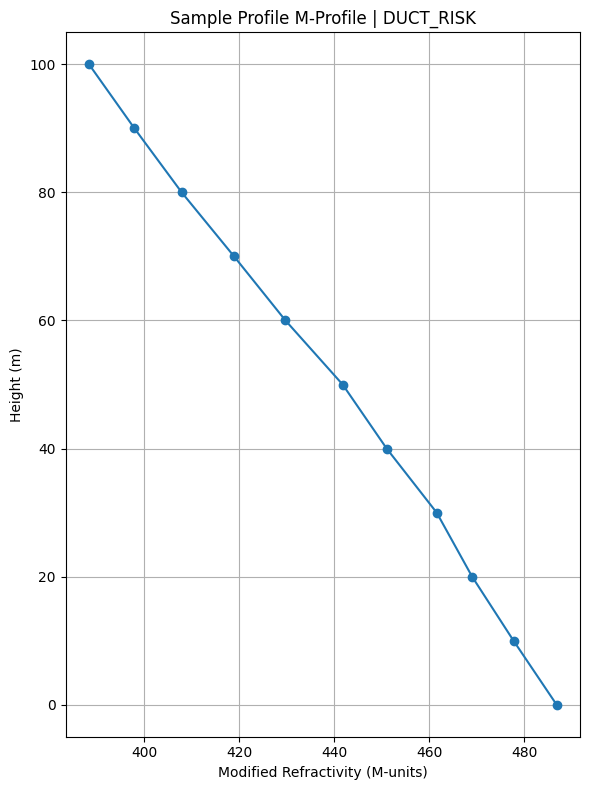

In [5]:
plt.figure(figsize=(6, 8))
plt.plot(m_profile, height_m, marker='o')
plt.xlabel('Modified Refractivity (M-units)')
plt.ylabel('Height (m)')
plt.title(f"Sample Profile M-Profile | {result['classification']}")
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretation

This notebook is not claiming operational prediction.
It demonstrates the PACL Layer 1 chain:

**profile data → M-profile → sensing-state interpretation**